In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/Salary_dataset.csv')

In [4]:
df.head(10)

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0
5,5,3.0,56643.0
6,6,3.1,60151.0
7,7,3.3,54446.0
8,8,3.3,64446.0
9,9,3.8,57190.0


In [5]:
df.tail(10)

,Unnamed: 0,YearsExperience,Salary
20,20,6.9,91739.0
21,21,7.2,98274.0
22,22,8.0,101303.0
23,23,8.3,113813.0
24,24,8.8,109432.0
25,25,9.1,105583.0
26,26,9.6,116970.0
27,27,9.7,112636.0
28,28,10.4,122392.0
29,29,10.6,121873.0


In [6]:
df.describe()

,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


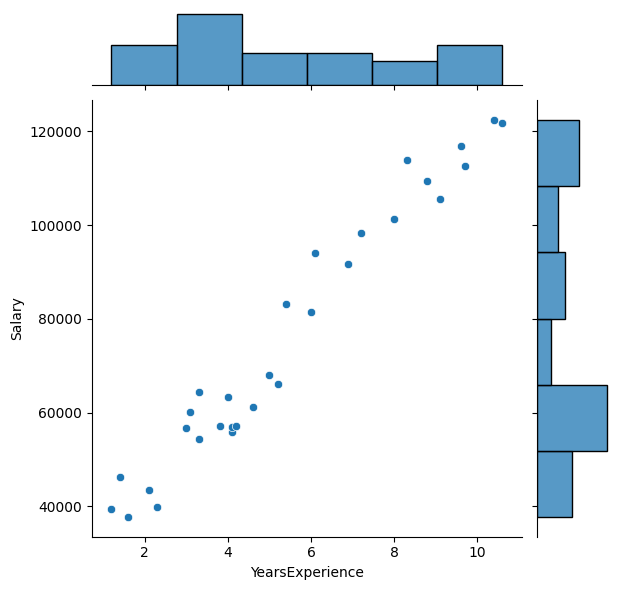

In [10]:
sns.jointplot(x='YearsExperience',y='Salary',data=df , kind="scatter")


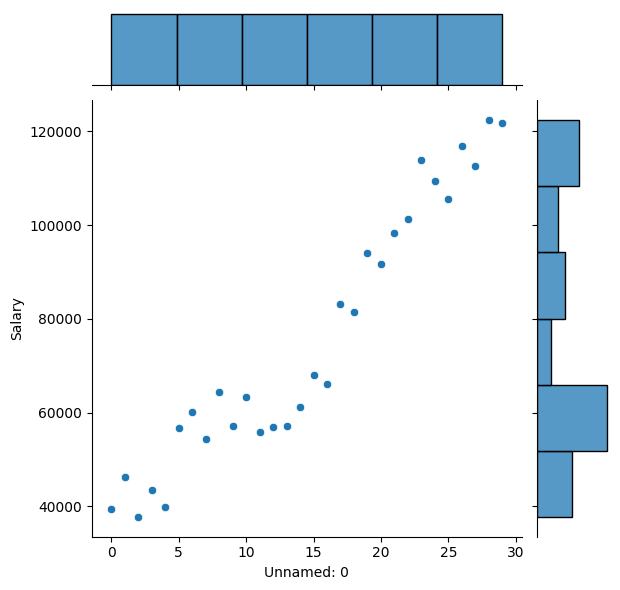

In [11]:

sns.jointplot(x='Unnamed: 0',y='Salary',data=df,kind='scatter')

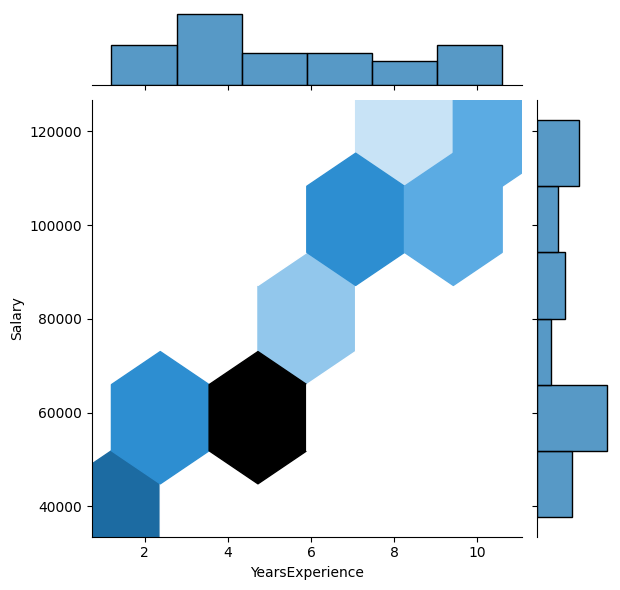

In [12]:
sns.jointplot(x='YearsExperience',y='Salary',data=df,kind='hex')

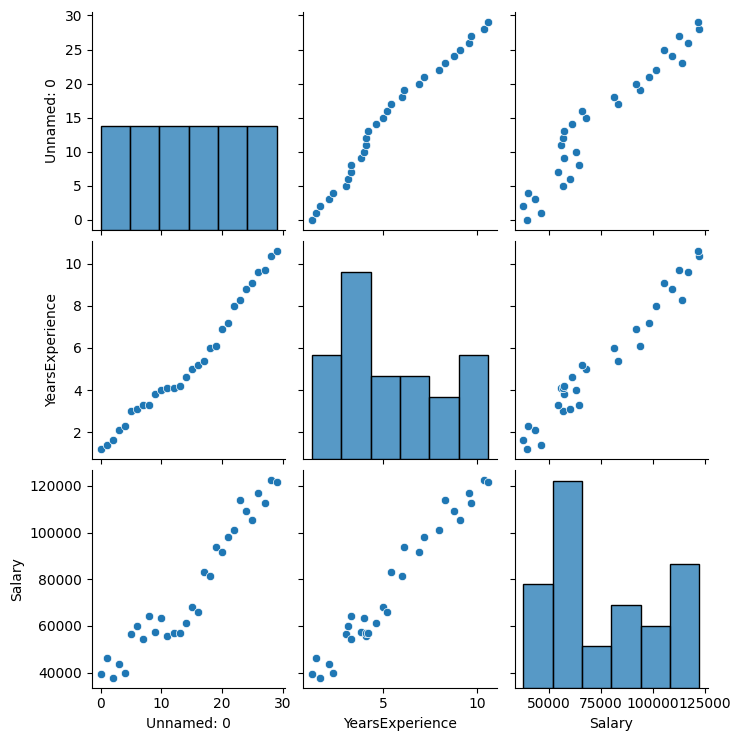

In [13]:

sns.pairplot(df)

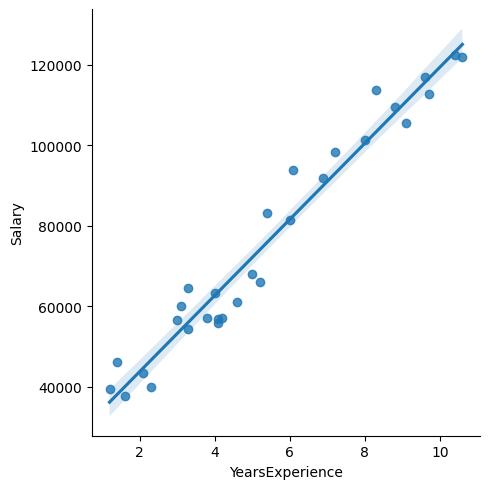

In [14]:
sns.lmplot(x='YearsExperience',y='Salary',data=df)

In [15]:
df.columns

Index(['Unnamed: 0', 'YearsExperience', 'Salary'], dtype='object')

In [19]:
X = df[['YearsExperience', "Unnamed: 0"]]

In [18]:

Y =df['Salary']

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=100)

In [22]:

from sklearn.linear_model import LinearRegression

In [23]:

lm = LinearRegression()

In [24]:

lm.fit(X_train,y_train)

LinearRegression()

In [25]:

coeff_df =pd.DataFrame(lm.coef_,X.columns,columns=['Coefficients'])
coeff_df

,Coefficients
YearsExperience,10020.937540
Unnamed: 0,-91.024315


In [42]:

predictions=lm.predict(X_test)

Text(0, 0.5, 'Y_predicted')

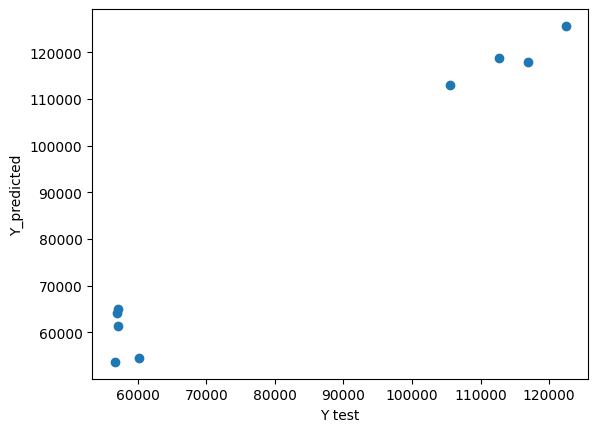

In [41]:

plt.scatter(y_test , predictions)
plt.xlabel('Y test')
plt.ylabel('Y_predicted')


In [28]:

from sklearn import metrics

In [38]:
print('MAE:', metrics.mean_absolute_error(y_test, predictions))

print('MSE:', metrics.mean_squared_error(y_test, predictions))

print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))

MAE: 5024.082602093648
MSE: 30131817.854730275
RMSE: 5489.245654434703


In [39]:
import gradio as gr

In [45]:
def predict_spending(
    YearsExperience,
    Salary,

):

    customer_data = [[
         YearsExperience,
         Salary,


    ]]

    prediction = lm.predict(customer_data)[0]

    return prediction

In [47]:
demo = gr.Interface(
    fn=predict_spending,

    inputs=[
        gr.Number(label="name"),
        gr.Number(label="Salary"),
        gr.Number(label="YearsExperience"),

    ],

    outputs=gr.Number(
        label="Predicted Yearly Amount Spent"
    ),

    title="Salary",

    description="Enter customer information to predict yearly amount of salary."
)

demo.launch()

/usr/local/lib/python3.13/dist-packages/gradio/utils.py:1281: UserWarning: Expected 2 arguments for function <function predict_spending at 0x7e8dd5c53100>, received 3.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/gradio/utils.py:1289: UserWarning: Expected maximum 2 arguments for function <function predict_spending at 0x7e8dd5c53100>, received 3.
  warnings.warn(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ec9394358534aaae5a.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [33]:
udemo = gr.Interface(
    fn=predict_spending,

    inputs=[
        gr.Slider(
            minimum=float(df['Avg. Session Length'].min()),
            maximum=float(df['Avg. Session Length'].max()),
            value=float(df['Avg. Session Length'].mean()),
            label="Avg. Session Length"
        ),

        gr.Slider(
            minimum=float(df['Time on App'].min()),
            maximum=float(df['Time on App'].max()),
            value=float(df['Time on App'].mean()),
            label="Time on App"
        ),

        gr.Slider(
            minimum=float(df['Time on Website'].min()),
            maximum=float(df['Time on Website'].max()),
            vale=float(df['Time on Website'].mean()),
            label="Time on Website"
        ),

        gr.Slider(
            minimum=float(df['Length of Membership'].min()),
            maximum=float(df['Length of Membership'].max()),
            value=float(df['Length of Membership'].mean()),
            label="Length of Membership"
        )
    ],

    outputs=gr.Number(
        label="Predicted Yearly Amount Spent"
    ),

    title="E-Commerce Customer Spending Predictor",
    description="Predict yearly customer spending using the trained Linear Regression model."
)

demo.launch()

KeyError: 'Avg. Session Length'